# Beyond Experience × Zid
## Case Study: Demand Forecasting for the Saudi National Day Season

In this case study, you work as a Machine Learning Specialist for an e-commerce store on Zid. The goal is to estimate how many units of each product should be stocked for the season and determine the best time to launch the promotional campaign. The workflow covers data loading, quality checks, integration, exploratory analysis, feature engineering, time-based validation, modeling, evaluation, forecasting, and business recommendations.


## Dataset Overview

The case study uses three files. `orders.csv` contains historical order-line records, `products.csv` contains product attributes and costs, and `calendar.csv` contains dates and seasonal or promotional indicators. Together, they support daily product-level demand forecasting.


## Data Loading

Load the three datasets and parse the date columns so that sales can be analyzed over time and matched with seasonal calendar indicators.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (13, 4)
RANDOM_STATE = 42

orders   = pd.read_csv("orders.csv",   parse_dates=["order_date"])
products = pd.read_csv("products.csv", parse_dates=["launch_date"])
calendar = pd.read_csv("calendar.csv", parse_dates=["date"])

for name, frame in [("orders", orders), ("products", products), ("calendar", calendar)]:
    print(f"{name:9s} {frame.shape}")


orders    (118602, 8)
products  (25, 5)
calendar  (771, 5)


## Data Preview

Preview a sample from each dataset to understand its columns and values.


In [3]:
display(orders.head())
display(products.head())
display(calendar.head())


,order_id,order_date,product_id,quantity,unit_price,discount_pct,city,channel
0,O100001,2024-07-01 20:00:00,P001,1,45,0,Makkah,app
1,O100002,2024-07-01 18:00:00,P001,1,45,0,Riyadh,app
2,O100003,2024-07-01 13:00:00,P001,2,45,0,Tabuk,app
3,O100004,2024-07-01 19:00:00,P001,2,45,0,Riyadh,web
4,O100005,2024-07-01 15:00:00,P001,2,45,0,Jeddah,app


,product_id,product_name,category,cost_price,launch_date
0,P001,"Saudi flag (large, outdoor)",Décor,18,2023-05-01
1,P002,Saudi flag (desk size),Décor,5,2023-05-01
2,P003,Green LED string lights 10m,Décor,14,2023-08-10
3,P004,National Day balloon & banner kit,Décor,22,2023-08-10
4,P005,Falcon wall art (metal),Décor,80,2023-11-02


,date,is_national_day_season,is_ramadan,is_eid,is_promo_day
0,2024-07-01,0,0,0,0
1,2024-07-02,0,0,0,0
2,2024-07-03,0,0,0,0
3,2024-07-04,0,0,0,0
4,2024-07-05,0,0,0,0


## Data Inspection

Inspect dataset shapes, column types, and memory usage before analysis.


In [4]:

for name, frame in [
    ("Orders", orders),
    ("Products", products),
    ("Calendar", calendar)
]:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(frame.info())


Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118602 entries, 0 to 118601
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      118602 non-null  object        
 1   order_date    118602 non-null  datetime64[ns]
 2   product_id    118602 non-null  object        
 3   quantity      118602 non-null  int64         
 4   unit_price    118602 non-null  int64         
 5   discount_pct  118602 non-null  int64         
 6   city          118602 non-null  object        
 7   channel       118602 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 7.2+ MB
None
Products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    25 non-null     object        
 1   product_name  25 non-null     obj

## Data Quality Check

Check missing values and duplicated rows because both can affect analysis and model accuracy.


In [5]:
for name, frame in [
    ("Orders", orders),
    ("Products", products),
    ("Calendar", calendar)
]:

    missing    = frame.isnull().sum().sum()

    duplicated = frame.duplicated().sum()

    print(f"{name:10s} | missing: {missing:>3} | duplicated: {duplicated:>3}")


Orders     | missing:   0 | duplicated:   0
Products   | missing:   0 | duplicated:   0
Calendar   | missing:   0 | duplicated:   0


## Data Integration

Join orders with product information, extract a normalized order date, and then join the calendar indicators. This produces one integrated sales table.


In [6]:
merged_df = orders.merge(products, on="product_id", how="left")


merged_df["date"] = pd.to_datetime(merged_df["order_date"].dt.date)


final_df = merged_df.merge(calendar, on="date", how="left")

print("final_df:", final_df.shape)
final_df.head()


final_df: (118602, 17)


,order_id,order_date,product_id,quantity,unit_price,discount_pct,city,channel,product_name,category,cost_price,launch_date,date,is_national_day_season,is_ramadan,is_eid,is_promo_day
0,O100001,2024-07-01 20:00:00,P001,1,45,0,Makkah,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
1,O100002,2024-07-01 18:00:00,P001,1,45,0,Riyadh,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
2,O100003,2024-07-01 13:00:00,P001,2,45,0,Tabuk,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
3,O100004,2024-07-01 19:00:00,P001,2,45,0,Riyadh,web,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
4,O100005,2024-07-01 15:00:00,P001,2,45,0,Jeddah,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0


## Data Preparation

Aggregate order lines into daily demand for every product. Build a complete date-product grid so days without recorded sales are represented as zero, then remove rows before each product's launch date.


In [7]:


daily = final_df.groupby(["date", "product_id"], as_index=False)["quantity"].sum()


grid = pd.MultiIndex.from_product(
    [calendar["date"], products["product_id"]],
    names=["date", "product_id"]
).to_frame(index=False)


df = (
    grid
    .merge(daily,    on=["date", "product_id"], how="left")
    .fillna({"quantity": 0})
    .merge(products, on="product_id")
    .merge(calendar, on="date")
)


df = df[df["date"] >= df["launch_date"]].copy()

print("daily:", daily.shape)
print("df   :", df.shape)
df.head()


daily: (18360, 3)
df   : (18547, 11)


,date,product_id,quantity,product_name,category,cost_price,launch_date,is_national_day_season,is_ramadan,is_eid,is_promo_day
0,2024-07-01,P001,12.0,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,0,0,0,0
1,2024-07-01,P002,9.0,Saudi flag (desk size),Décor,5,2023-05-01,0,0,0,0
2,2024-07-01,P003,8.0,Green LED string lights 10m,Décor,14,2023-08-10,0,0,0,0
3,2024-07-01,P004,5.0,National Day balloon & banner kit,Décor,22,2023-08-10,0,0,0,0
4,2024-07-01,P005,3.0,Falcon wall art (metal),Décor,80,2023-11-02,0,0,0,0


## Exploratory Data Analysis (EDA)

Explore best-selling products, recurring seasonal patterns, demand trends, and unusual events that may affect forecasting and inventory decisions.


### Seasonal Patterns in Purchase Behavior

Examine demand by day of week and compare purchase times during Ramadan with regular periods.


In [8]:
orders["day_of_week"] = orders["order_date"].dt.dayofweek

weekly_share = orders.groupby("day_of_week")["quantity"].sum()
weekly_share = (weekly_share / weekly_share.sum() * 100).round(1)

DAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly_share.index = DAY_NAMES

print("Share of total sales by day (%)")
print(weekly_share.to_string())
print("\nFriday and Saturday combined:", round(weekly_share.loc["Friday"] + weekly_share.loc["Saturday"], 1), "%")

orders["hour"] = orders["order_date"].dt.hour
orders["date"] = orders["order_date"].dt.normalize()

orders_with_calendar = orders.merge(calendar, on="date", how="left")

ramadan_hour = orders_with_calendar.loc[orders_with_calendar["is_ramadan"] == 1, "hour"].mean()
normal_hour  = orders_with_calendar.loc[orders_with_calendar["is_ramadan"] == 0, "hour"].mean()

print("\nAverage order hour during Ramadan:", round(ramadan_hour, 1))
print("Average order hour outside Ramadan:", round(normal_hour, 1))


Share of total sales by day (%)
Monday       13.1
Tuesday      12.8
Wednesday    12.8
Thursday     12.8
Friday       17.9
Saturday     17.6
Sunday       13.0

Friday and Saturday combined: 35.5 %

Average order hour during Ramadan: 2.1
Average order hour outside Ramadan: 16.3


The results show that Friday and Saturday account for a substantial share of demand. Purchases also shift to later hours during Ramadan, confirming recurring temporal patterns in customer behavior.


### Seasonality by Product and Category

Compare category shares and product-level average demand inside and outside the National Day season.


Category share of sales:


,Regular %,Season %,Difference
category,,,
Accessories,20.6,20.4,-0.2
Apparel,17.4,18.3,0.9
Décor,35.3,37.2,1.9
Gifts,26.7,24.1,-2.6


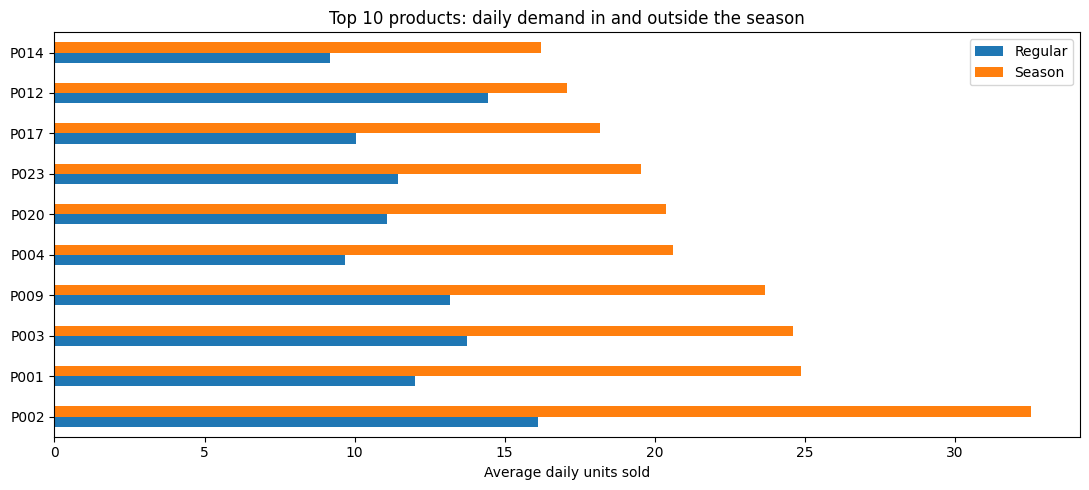

,product_name,Regular,Season,Multiplier
product_id,,,,
P002,Saudi flag (desk size),16.10,32.55,2.02
P001,"Saudi flag (large, outdoor)",12.03,24.88,2.07
P003,Green LED string lights 10m,13.74,24.60,1.79
P009,SA flag mug,13.17,23.67,1.80
P004,National Day balloon & banner kit,9.67,20.62,2.13
P020,Face-paint & stickers pack,11.10,20.38,1.84
P023,Green LED wristbands (5-pack),11.46,19.55,1.71
P017,'KSA 96' t-shirt,10.04,18.19,1.81
P012,Personalized keychain (name),14.45,17.10,1.18


In [9]:

seasonal = df[df["is_national_day_season"] == 1]
regular  = df[df["is_national_day_season"] == 0]

cat_season  = seasonal.groupby("category")["quantity"].sum()
cat_regular = regular.groupby("category")["quantity"].sum()

category_view = pd.DataFrame({
    "Regular %": (cat_regular / cat_regular.sum() * 100).round(1),
    "Season %": (cat_season  / cat_season.sum()  * 100).round(1),
})
category_view["Difference"] = (category_view["Season %"] - category_view["Regular %"]).round(1)

print("Category share of sales:")
display(category_view)

prod = pd.DataFrame({
    "Regular":  regular.groupby("product_id")["quantity"].mean(),
    "Season":  seasonal.groupby("product_id")["quantity"].mean(),
})
prod["Multiplier"] = (prod["Season"] / prod["Regular"]).round(2)
prod = prod.join(products.set_index("product_id")["product_name"])
top = prod.sort_values("Season", ascending=False).head(10)

ax = top[["Regular", "Season"]].plot(kind="barh", figsize=(11, 5))
ax.set_xlabel("Average daily units sold")
ax.set_ylabel("")
plt.title("Top 10 products: daily demand in and outside the season")
plt.tight_layout(); plt.show()

display(top[["product_name", "Regular", "Season", "Multiplier"]].round(2))


### Demand Trend Over Time

Review total daily demand across the full period and identify the products contributing most to total sales.


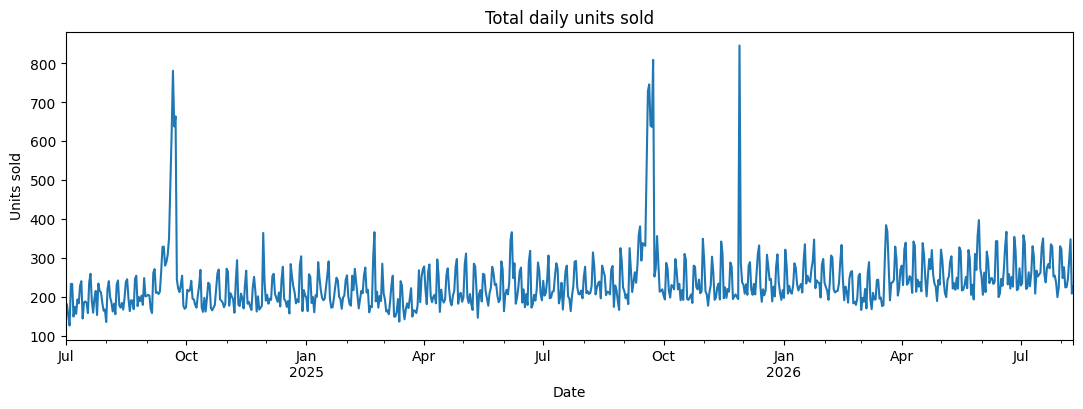

In [10]:

daily_total = (
    df.groupby("date")["quantity"]
      .sum()
      .sort_index()
)

daily_total.plot()

plt.title("Total daily units sold")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.show()


In [11]:

top_products = (
    df.groupby(["product_id", "product_name"], as_index=False)["quantity"]
      .sum()
      .sort_values("quantity", ascending=False)
      .head(10)
)

display(top_products)


,product_id,product_name,quantity
1,P002,Saudi flag (desk size),13102.0
11,P012,Personalized keychain (name),11250.0
2,P003,Green LED string lights 10m,11052.0
8,P009,SA flag mug,10597.0
0,P001,"Saudi flag (large, outdoor)",9815.0
22,P023,Green LED wristbands (5-pack),9013.0
19,P020,Face-paint & stickers pack,8946.0
6,P007,Scented candle set (oud),8447.0
16,P017,'KSA 96' t-shirt,8086.0
3,P004,National Day balloon & banner kit,7914.0


### Outlier Detection

Use the interquartile range (IQR) method to identify days with unusually high demand and investigate their causes.


In [12]:

q1 = daily_total.quantile(0.25)
q3 = daily_total.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outlier_days = daily_total[daily_total > upper_bound]

median_demand = daily_total.median()

outlier_report = pd.DataFrame({
    "quantity": outlier_days,
    "multiplier": (outlier_days / median_demand).round(1),
})

print("Median daily demand:", median_demand)
display(outlier_report.sort_values("quantity", ascending=False))


Median daily demand: 220.0


,quantity,multiplier
date,,
2025-11-28,846.0,3.8
2025-09-23,809.0,3.7
2024-09-21,781.0,3.6
2025-09-20,746.0,3.4
2025-09-19,729.0,3.3
2024-09-23,664.0,3.0
2025-09-21,640.0,2.9
2024-09-22,638.0,2.9
2025-09-22,637.0,2.9


### Selecting the Promotional Campaign Launch Date

Track demand before National Day to identify when customer demand begins to rise materially above the August baseline.


In [13]:
# Identify the first September ramp-up date in 2024 and 2025.
daily_total = df.groupby("date")["quantity"].sum().sort_index()
ramp_up_dates = {}

for year in [2024, 2025]:
    august_baseline = daily_total[f"{year}-08-01":f"{year}-08-25"].mean()
    september = daily_total[f"{year}-09-01":f"{year}-09-25"]
    candidates = september[september > august_baseline * 1.50]
    ramp_up_day = candidates.index.min() if not candidates.empty else pd.NaT
    ramp_up_dates[year] = ramp_up_day
    print(year,
          "| August baseline:", round(august_baseline),
          "| Demand ramp-up:", ramp_up_day.date() if pd.notna(ramp_up_day) else "Not detected")


2024 | August baseline: 197 | Demand ramp-up: 2024-09-13
2025 | August baseline: 235 | Demand ramp-up: 2025-09-12


### Special Cases in the Data

Some observations require special interpretation before modeling because they may not represent normal demand.


### Cases Requiring Special Treatment

The analysis considers three cases: stockouts, non-recurring promotional events, and newly launched products. Each case requires a different treatment.


#### Stockout

Zero recorded sales may reflect unavailable inventory rather than zero demand. Product P004 is examined for this issue.


In [14]:
# Inspect daily sales for P004 around the suspected stockout.
p004 = daily[daily["product_id"] == "P004"].set_index("date")["quantity"]
window = pd.date_range("2025-08-25", "2025-09-30")
series = p004.reindex(window, fill_value=0)
zero_days = series[series == 0]

print("Zero-sales days:", len(zero_days))
print("From:", zero_days.index.min().date(), "to:", zero_days.index.max().date())
print("Average before the gap:", round(series[:"2025-08-31"].mean(), 1))
print("Average after the gap:", round(series["2025-09-15":].mean(), 1))
display(series)


Zero-sales days: 14
From: 2025-09-01 to: 2025-09-14
Average before the gap: 11.4
Average after the gap: 24.9


,quantity
2025-08-25,10
2025-08-26,12
2025-08-27,10
2025-08-28,10
2025-08-29,7
2025-08-30,22
2025-08-31,9
2025-09-01,0
2025-09-02,0
2025-09-03,0


#### Non-Recurring Promotional Event

An outlier may be caused by a one-time promotion rather than repeatable seasonality. Check the calendar promotion flag for the largest outlier outside September.


In [15]:
non_september = outlier_days[outlier_days.index.month != 9]

outlier_date  = non_september.idxmax()

promo_flag    = calendar.loc[calendar["date"] == outlier_date, "is_promo_day"].iloc[0]

print("Date:", outlier_date.date())
print("Quantity:", int(non_september.max()))
print("Multiplier:", round(non_september.max() / daily_total.median(), 1))
print("is_promo_day:", promo_flag)


Date: 2025-11-28
Quantity: 846
Multiplier: 3.8
is_promo_day: 1


#### Newly Launched Products

New products have insufficient history for year-over-year forecasting. Product P025 is evaluated using an analogy with products in the same category.


In [16]:

p025_launch = products.loc[products["product_id"] == "P025", "launch_date"].iloc[0]

national_day_dates = calendar.loc[calendar["is_national_day_season"] == 1, "date"]
seasons_seen = (national_day_dates >= p025_launch).sum()

category = products.loc[products["product_id"] == "P025", "category"].iloc[0]
peers = products.loc[
    (products["category"] == category) & (products["product_id"] != "P025"),
    "product_id"
]

season  = daily[(daily["date"] >= "2025-09-13") & (daily["date"] <= "2025-10-03")]
august  = daily[(daily["date"] >= "2025-08-01") & (daily["date"] <= "2025-08-25")]

multipliers = [
    (season.loc[season["product_id"] == pid, "quantity"].sum() / 21)
    / max(august.loc[august["product_id"] == pid, "quantity"].sum() / 25, 0.01)
    for pid in peers
]

season_multiplier = np.mean(multipliers)

print("Launch date:", p025_launch.date())
print("Season days observed after launch:", seasons_seen)
print("Category:", category)
print("Category peer seasonal multiplier:", round(season_multiplier, 2))


Launch date: 2026-06-15
Season days observed after launch: 0
Category: Décor
Category peer seasonal multiplier: 1.65


P025 cannot be forecast reliably from its own seasonal history because it has not completed a prior National Day season. Its estimate is therefore based on comparable products in the same category and is assigned lower confidence.


## Feature Engineering

Create time features, encode product and category variables, add seasonal indicators, and construct a 365-day lag representing demand for the same product one year earlier.


### Repairing the Stockout Period

P004 recorded zero sales for fourteen days because of a stockout. Replace those days with the corresponding prior-year demand adjusted by store growth, using only information available before the test period to prevent leakage.


In [17]:

GAP_PRODUCT = "P004"
GAP_START, GAP_END = pd.Timestamp("2025-09-01"), pd.Timestamp("2025-09-14")

aug_2024 = df.loc[df["date"].between("2024-08-01", "2024-08-25"), "quantity"].sum()
aug_2025 = df.loc[df["date"].between("2025-08-01", "2025-08-25"), "quantity"].sum()
STORE_GROWTH = aug_2025 / aug_2024

gap_days = pd.date_range(GAP_START, GAP_END)

prior_year = (daily[daily["product_id"] == GAP_PRODUCT]
              .set_index("date")["quantity"]
              .reindex(gap_days - pd.Timedelta(days=365))
              .fillna(0))

estimates = (prior_year.values * STORE_GROWTH).round()

gap_rows = pd.DataFrame({
    "date": gap_days,
    "product_id": GAP_PRODUCT,
    "quantity": estimates,
})

mask = ((daily["product_id"] == GAP_PRODUCT)
        & daily["date"].between(GAP_START, GAP_END))

daily = pd.concat([daily[~mask], gap_rows], ignore_index=True)
daily = daily.sort_values(["date", "product_id"]).reset_index(drop=True)

df = df.merge(gap_rows.rename(columns={"quantity": "repaired"}),
              on=["date", "product_id"], how="left")
df["quantity"] = df["repaired"].fillna(df["quantity"])
df = df.drop(columns=["repaired"])

print("Estimates used for stockout days:")
print(pd.Series(estimates.astype(int), index=gap_days.date).to_string())


Estimates used for stockout days:
2025-09-01    19
2025-09-02    16
2025-09-03     8
2025-09-04     4
2025-09-05    12
2025-09-06    16
2025-09-07    17
2025-09-08    10
2025-09-09     8
2025-09-10    13
2025-09-11    12
2025-09-12    16
2025-09-13    22
2025-09-14    18


### Categorical Encoding

Random Forest requires numeric inputs. Encode product and category values numerically. These codes identify groups but do not imply a meaningful rank.


In [18]:
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

df["product_id_encoded"] = df["product_id"].str[1:].astype(int)
df["category_encoded"]   = df["category"].astype("category").cat.codes

lag = df[["date", "product_id", "quantity"]].copy()
lag["date"] = lag["date"] + pd.Timedelta(days=365)
lag = lag.rename(columns={"quantity": "lag_365"})

df = df.merge(lag, on=["date", "product_id"], how="left")

df["lag_365"] = df["lag_365"].fillna(-1)

df[["date", "product_id", "quantity", "lag_365"]].head()


,date,product_id,quantity,lag_365
0,2024-07-01,P001,12.0,-1.0
1,2024-07-01,P002,9.0,-1.0
2,2024-07-01,P003,8.0,-1.0
3,2024-07-01,P004,5.0,-1.0
4,2024-07-01,P005,3.0,-1.0


In [19]:

FEATURES = [
    "product_id_encoded",
    "category_encoded",
    "day_of_week",
    "month",
    "is_national_day_season",
    "is_promo_day",
    "lag_365",
]

TARGET = "quantity"

print("Number of features:", len(FEATURES))
print("Rows without prior-year history:", (df["lag_365"] == -1).sum())


Number of features: 7
Rows without prior-year history: 8817


### Feature Selection

The selected features represent product identity, category, weekly and monthly timing, National Day seasonality, promotion status, and prior-year demand. All are available before the forecast period.


## Temporal Train-Test Split

Split the data by date rather than randomly. Train on earlier observations and test on the complete 2025 National Day season to simulate forecasting future demand.


In [20]:

SPLIT_DATE = pd.Timestamp("2025-09-13")
TEST_END = pd.Timestamp("2025-10-03")



train = df[df["date"] < SPLIT_DATE].copy()


test  = df[(df["date"] >= SPLIT_DATE) & (df["date"] <= TEST_END)].copy()

print(f"Train rows: {len(train):,}")
print(f"Test rows : {len(test):,}")


Train rows: 10,522
Test rows : 504


## Model Training

Train a `RandomForestRegressor` on the engineered features and evaluate its demand predictions on the held-out period.


### Baseline Model

Use prior-year demand adjusted by store growth as a practical baseline. The machine-learning model is useful only if it performs better than this simple benchmark.


In [21]:
# Build the year-over-year growth-adjusted baseline.
august_2024 = df.loc[df["date"].between("2024-08-01", "2024-08-25"), "quantity"].sum()
august_2025 = df.loc[df["date"].between("2025-08-01", "2025-08-25"), "quantity"].sum()
GROWTH_RATE = august_2025 / august_2024

print(f"Calculated growth rate: {GROWTH_RATE:.3f}")
test["baseline"] = test["lag_365"].clip(lower=0) * GROWTH_RATE
baseline_mae = mean_absolute_error(test[TARGET], test["baseline"])
print(f"Baseline MAE: {baseline_mae:.2f}")


Calculated growth rate: 1.195
Baseline MAE: 6.57


The seasonal growth rate is lower than the store's long-run growth rate because it compares equivalent seasonal periods. Using the broader rate here would overstate the baseline forecast.


In [22]:
# Train and evaluate the Random Forest model.
model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(train[FEATURES], train[TARGET])
test["prediction"] = model.predict(test[FEATURES]).clip(0)
mae = mean_absolute_error(test[TARGET], test["prediction"])
rmse = np.sqrt(np.mean((test[TARGET] - test["prediction"]) ** 2))
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE : 5.11
RMSE: 6.90


## Model Evaluation

Evaluate predictions with Mean Absolute Error (MAE), which reports the average absolute difference between predicted and actual daily units. Lower values indicate better accuracy.


### Tuning `n_estimators`

Compare several tree counts and select a value that provides stable MAE without unnecessary training time.


In [23]:

for n in [10, 50, 100, 300, 500]:
    m = RandomForestRegressor(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(train[FEATURES], train[TARGET])
    e = mean_absolute_error(test[TARGET], m.predict(test[FEATURES]).clip(0))
    print(f"Trees {n:>4}  ->  MAE {e:.3f}")


Trees   10  ->  MAE 5.223
Trees   50  ->  MAE 5.115
Trees  100  ->  MAE 5.109
Trees  300  ->  MAE 5.106
Trees  500  ->  MAE 5.109


MAE improves as the number of trees increases and then stabilizes. A value of 300 trees provides stable performance without unnecessary computation.


## Generating Predictions

Compare predicted and actual demand by product during the test period before forecasting the next season.


In [24]:

results = (
    test.groupby(["product_id", "product_name"], as_index=False)
        .agg(actual=("quantity", "sum"), predicted=("prediction", "sum"))
)

results["predicted"] = results["predicted"].round().astype(int)
results["difference"] = results["predicted"] - results["actual"]

display(results.sort_values("actual", ascending=False).head(10))


,product_id,product_name,actual,predicted,difference
1,P002,Saudi flag (desk size),758.0,685,-73.0
8,P009,SA flag mug,561.0,476,-85.0
2,P003,Green LED string lights 10m,560.0,503,-57.0
0,P001,"Saudi flag (large, outdoor)",538.0,561,23.0
3,P004,National Day balloon & banner kit,471.0,472,1.0
22,P023,Green LED wristbands (5-pack),454.0,387,-67.0
19,P020,Face-paint & stickers pack,442.0,421,-21.0
16,P017,'KSA 96' t-shirt,430.0,345,-85.0
11,P012,Personalized keychain (name),396.0,355,-41.0
13,P014,Green & white gift wrap set,345.0,356,11.0


The `difference` column equals predicted demand minus actual demand. Negative values indicate underprediction, while positive values indicate overprediction.


## Assessing Model Fit

Compare training and test MAE. A much lower training error than test error may indicate overfitting and weaker generalization.


### Seasonal Percentage Error by Product

Compute percentage error at the whole-season product level rather than the daily level. This avoids unstable percentages on zero-sales days and supports product-level confidence labels.


In [25]:
# Compare training and test error and calculate seasonal product-level MAPE.
train_mae = mean_absolute_error(train[TARGET], model.predict(train[FEATURES]).clip(0))
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Gap      : {mae - train_mae:.2f}")

def seasonal_ape_per_product(frame, pred_col):
    grouped = frame.groupby("product_id").agg(actual=("quantity", "sum"), pred=(pred_col, "sum"))
    grouped = grouped[grouped["actual"] > 0]
    return np.abs(grouped["actual"] - grouped["pred"]) / grouped["actual"] * 100

per_product_mape = seasonal_ape_per_product(test, "prediction")
model_mape = per_product_mape.mean()
baseline_mape = seasonal_ape_per_product(test, "baseline").mean()

print(f"\n{'':<10}{'MAE':>9}{'MAPE':>9}")
print(f"{'Baseline':<10}{baseline_mae:>9.2f}{baseline_mape:>8.1f}%")
print(f"{'Model':<10}{mae:>9.2f}{model_mape:>8.1f}%")
print("\nProducts with MAPE >= 30%:", list(per_product_mape[per_product_mape >= 30].index))
print("\nSeasonal percentage error by product:")
print(per_product_mape.round(1).sort_values(ascending=False).to_string())


Train MAE: 2.58
Test MAE : 5.11
Gap      : 2.53

                MAE     MAPE
Baseline       6.57    11.1%
Model          5.11    12.0%

Products with MAPE >= 30%: ['P011']

Seasonal percentage error by product:
product_id
P011    30.3
P018    20.6
P019    20.6
P017    19.7
P013    18.0
P015    15.6
P009    15.2
P022    15.0
P023    14.7
P006    14.1
P010    13.8
P007    12.8
P016    12.7
P008    12.1
P012    10.3
P003    10.1
P002     9.6
P024     4.8
P020     4.8
P001     4.2
P005     3.7
P014     3.3
P021     1.6
P004     0.3


### Interpretation

The model achieves lower MAE than the baseline. Product-level seasonal MAPE identifies forecasts that require extra caution, particularly when the error reaches 30% or more.


## Validation Across Multiple Time Windows

Repeat training and evaluation across consecutive historical windows. Recalculate baseline growth using only information available before each window.


In [26]:

def historical_growth(frame, cutoff, days=25):
    """Calculate growth using only data available before the evaluation window."""
    current_end   = cutoff - pd.Timedelta(days=1)
    current_start = current_end - pd.Timedelta(days=days - 1)

    previous_start = current_start - pd.DateOffset(years=1)
    previous_end   = current_end   - pd.DateOffset(years=1)

    current  = frame.loc[frame["date"].between(current_start, current_end), "quantity"].sum()
    previous = frame.loc[frame["date"].between(previous_start, previous_end), "quantity"].sum()

    return current / previous if previous > 0 else 1.0


results = []

for start in pd.date_range("2025-06-01", "2026-07-01", freq="MS"):
    end = start + pd.Timedelta(days=20)

    tr = df[df["date"] < start]
    te = df[(df["date"] >= start) & (df["date"] <= end)]

    if len(te) < 100 or len(tr) < 3000:
        continue

    m = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(tr[FEATURES], tr[TARGET])

    results.append({
        "window":   str(start.date()),
        "model_mae": mean_absolute_error(te[TARGET], m.predict(te[FEATURES]).clip(0)),
        "base_mae":  mean_absolute_error(
            te[TARGET],
            te["lag_365"].clip(lower=0) * historical_growth(df, start)),
    })

windows = pd.DataFrame(results)
display(windows.round(2))

print(f"Average model MAE: {windows['model_mae'].mean():.2f}")
print(f"MAE standard deviation: {windows['model_mae'].std():.2f}")
print(f"Model beats baseline in {(windows['model_mae'] < windows['base_mae']).sum()}"
      f" of {len(windows)} windows")


,window,model_mae,base_mae
0,2025-06-01,3.73,9.90
1,2025-07-01,3.61,4.95
2,2025-08-01,3.76,5.20
3,2025-09-01,4.70,6.35
4,2025-10-01,3.90,5.03
5,2025-11-01,3.60,4.86
6,2025-12-01,3.54,5.22
7,2026-01-01,3.75,5.25
8,2026-02-01,3.44,4.81
9,2026-03-01,3.86,4.98


Average model MAE: 3.82
MAE standard deviation: 0.30
Model beats baseline in 14 of 14 windows


### Interpretation

The model outperforms the baseline across all evaluated windows. September has the highest model error because National Day creates a larger demand shift than ordinary periods.


## Translating Forecast Error into Financial Impact

Overprediction creates excess inventory cost, while underprediction can cause lost sales. Convert both error types into monetary values to support the inventory decision.


## Testing Additional Seasonal Features

Add Ramadan and Eid indicators and compare model performance to determine whether they improve the National Day forecast.


In [27]:

FEATURES_EXTENDED = FEATURES + ["is_ramadan", "is_eid"]

model_extended = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
).fit(train[FEATURES_EXTENDED], train[TARGET])

mae_extended = mean_absolute_error(
    test[TARGET],
    model_extended.predict(test[FEATURES_EXTENDED]).clip(0),
)

print(f"MAE with current features : {mae:.3f}")
print(f"MAE after adding features: {mae_extended:.3f}")


MAE with current features : 5.106
MAE after adding features: 5.102


### Interpretation

Ramadan and Eid indicators do not materially improve performance because the forecast period does not overlap those events. Features should be retained based on measured value rather than availability alone.


## Feature Importance


,feature,importance
0,product_id_encoded,0.384962
1,day_of_week,0.169278
2,month,0.168001
3,is_promo_day,0.130806
4,lag_365,0.082106
5,is_national_day_season,0.042971
6,category_encoded,0.021875


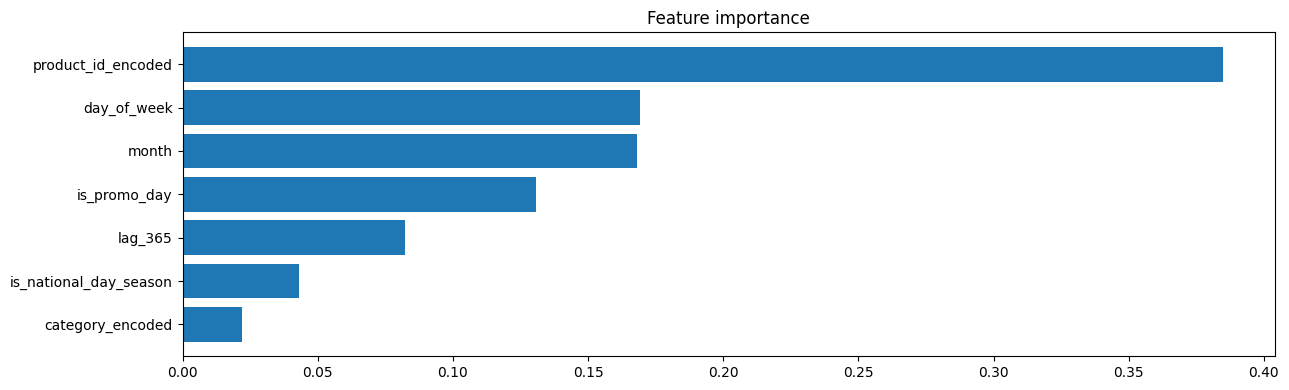

In [28]:

importance = (
    pd.DataFrame({
        "feature": FEATURES,
        "importance": model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance)

plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.title("Feature importance")
plt.tight_layout()
plt.show()


In [29]:

tree_predictions = np.stack([
    tree.predict(test[FEATURES]).clip(0) for tree in model.estimators_
])

coverage_rows = []

for product in sorted(test["product_id"].unique()):
    mask = (test["product_id"] == product).values

    season_totals = tree_predictions[:, mask].sum(axis=1)
    lower, upper  = np.percentile(season_totals, [10, 90])
    actual        = test.loc[mask, "quantity"].sum()

    coverage_rows.append({
        "product_id": product,
        "actual":  int(actual),
        "lower":   int(lower),
        "upper":   int(upper),
        "covered": bool(lower <= actual <= upper),
    })

coverage = pd.DataFrame(coverage_rows)

display(coverage.head(10))
print("Coverage rate:", f"{coverage['covered'].mean():.0%}")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWa

,product_id,actual,lower,upper,covered
0,P001,538,505,612,True
1,P002,758,630,736,False
2,P003,560,444,562,True
3,P004,471,415,529,True
4,P005,154,131,191,True
5,P006,160,113,163,True
6,P007,276,202,273,False
7,P008,196,146,200,True
8,P009,561,428,525,False
9,P010,337,250,330,False


Coverage rate: 62%


### Interpretation

The interval table summarizes prediction variability across trees and whether each product's actual seasonal demand falls inside the estimated range. It is an uncertainty indicator, not a guarantee.


## Summary

A demand forecasting model was built from historical sales and engineered features, compared with a baseline, and validated before being used for the 2026 National Day forecast.


## Forecasting the 2026 National Day Season

Retrain the final model on all available observations and create a future date-product grid for 13 September through 3 October 2026.


In [30]:

model_final = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_final.fit(df[FEATURES], df[TARGET])

print("Evaluation-model training rows:", f"{len(train):,}")
print("Final-model training rows:", f"{len(df):,}")
print("National Day seasons observed by final model: 2024 and 2025")


Evaluation-model training rows: 10,522
Final-model training rows: 18,547
National Day seasons observed by final model: 2024 and 2025


In [31]:
FORECAST_START = pd.Timestamp("2026-09-13")
FORECAST_END   = pd.Timestamp("2026-10-03")

future = pd.MultiIndex.from_product(
    [pd.date_range(FORECAST_START, FORECAST_END), products["product_id"]],
    names=["date", "product_id"]
).to_frame(index=False).merge(products, on="product_id")

future = future[future["date"] >= future["launch_date"]].copy()

future["day_of_week"]        = future["date"].dt.dayofweek
future["month"]              = future["date"].dt.month
future["product_id_encoded"] = future["product_id"].str[1:].astype(int)
future["category_encoded"]   = future["category"].astype("category").cat.codes

future["is_national_day_season"] = 1
future["is_promo_day"] = 0

future = future.merge(lag, on=["date", "product_id"], how="left")
future["lag_365"] = future["lag_365"].fillna(-1)

print("Forecast-period rows:", future.shape[0])
print("Products without prior-year history:",
      sorted(future.loc[future["lag_365"] == -1, "product_id"].unique()))


Forecast-period rows: 525
Products without prior-year history: ['P025']


### Forecast Assumptions

Forecast baseline demand without assuming a future promotional campaign. The forecast is an input to campaign and inventory decisions, not a result of those decisions.


### Financial Cost of Error

Underprediction is valued as potential lost revenue, while overprediction is valued as additional inventory cost.


In [32]:

test["error"]      = test["prediction"] - test[TARGET]
test["cost_price"] = test["product_id"].map(products.set_index("product_id")["cost_price"])
test["sale_price"] = test["product_id"].map(orders.groupby("product_id")["unit_price"].mean())

over  = test[test["error"] > 0]
under = test[test["error"] < 0]

overstock_cost = (over["error"] * over["cost_price"]).sum()
lost_revenue   = (-under["error"] * under["sale_price"]).sum()

print("Overpredicted days:", len(over), "|", f"SAR {overstock_cost:,.0f}")
print("Underpredicted days:", len(under), "|", f"SAR {lost_revenue:,.0f}")
print("\nCost ratio:", round(lost_revenue / overstock_cost, 1), "times")


Overpredicted days: 233 | SAR 25,358
Underpredicted days: 271 | SAR 89,667

Cost ratio: 3.5 times


### Interpretation

Underprediction is financially more expensive than overprediction in the test results. A safety-stock margin is therefore added to the final inventory recommendation.


## Inventory Plan

Convert product forecasts into recommended stock using a 15% safety margin, estimated acquisition cost, and product-level confidence.


In [33]:
# Convert the 2026 forecast into an inventory recommendation.
SAFETY = 1.15
future["prediction"] = model_final.predict(future[FEATURES]).clip(0)

stock = (
    future.groupby("product_id", as_index=False)["prediction"].sum()
          .rename(columns={"prediction": "predicted_demand"})
          .merge(products[["product_id", "product_name", "cost_price"]], on="product_id")
)
stock["predicted_demand"] = stock["predicted_demand"].round().astype(int)
stock["recommended_stock"] = (stock["predicted_demand"] * SAFETY).round().astype(int)
stock["estimated_cost"] = stock["recommended_stock"] * stock["cost_price"]
stock["mape"] = stock["product_id"].map(per_product_mape).round(1).fillna(99.9)
stock["confidence"] = np.where(stock["mape"] < 30, "high", "low")

print("Total predicted demand:", f"{stock['predicted_demand'].sum():,}", "units")
print("Estimated full-plan cost:", f"SAR {stock['estimated_cost'].sum():,}")
display(stock.sort_values("predicted_demand", ascending=False))


Total predicted demand: 6,792 units
Estimated full-plan cost: SAR 185,597


,product_id,predicted_demand,product_name,cost_price,recommended_stock,estimated_cost,mape,confidence
1,P002,531,Saudi flag (desk size),5,611,3055,9.6,high
2,P003,450,Green LED string lights 10m,14,518,7252,10.1,high
8,P009,399,SA flag mug,10,459,4590,15.2,high
0,P001,389,"Saudi flag (large, outdoor)",18,447,8046,4.2,high
11,P012,342,Personalized keychain (name),8,393,3144,10.3,high
22,P023,321,Green LED wristbands (5-pack),5,369,1845,14.7,high
16,P017,304,'KSA 96' t-shirt,20,350,7000,19.7,high
3,P004,304,National Day balloon & banner kit,22,350,7700,0.3,high
19,P020,291,Face-paint & stickers pack,7,335,2345,4.8,high
18,P019,276,Green cap (embroidered),16,317,5072,20.6,high


### Correcting the Newly Launched Product Estimate

P025 has no prior seasonal history. Replace its model forecast with an analogy estimate based on recent demand and the seasonal multiplier of comparable products, while retaining low confidence.


In [34]:
# Replace the newly launched product forecast with a category analogy estimate.
NEW_PRODUCT = "P025"
recent_daily = df.loc[(df["product_id"] == NEW_PRODUCT)
                      & df["date"].between("2026-07-01", "2026-08-10"),
                      "quantity"].mean()
season_days = (FORECAST_END - FORECAST_START).days + 1
analogy_estimate = int(round(recent_daily * season_multiplier * season_days))
model_estimate = int(stock.loc[stock["product_id"] == NEW_PRODUCT, "predicted_demand"].iloc[0])

print("Model estimate:", model_estimate, "units")
print("Category analogy estimate:", analogy_estimate, "units")
stock.loc[stock["product_id"] == NEW_PRODUCT, "predicted_demand"] = analogy_estimate
stock.loc[stock["product_id"] == NEW_PRODUCT, "recommended_stock"] = int(round(analogy_estimate * SAFETY))
stock.loc[stock["product_id"] == NEW_PRODUCT, "confidence"] = "low"
stock["estimated_cost"] = stock["recommended_stock"] * stock["cost_price"]
display(stock[stock["product_id"] == NEW_PRODUCT])

print("\nAfter correcting the newly launched product:")
print("Total predicted demand:", f"{stock['predicted_demand'].sum():,}", "units")
print("Estimated full-plan cost:", f"SAR {stock['estimated_cost'].sum():,}")


Model estimate: 248 units
Category analogy estimate: 397 units


,product_id,predicted_demand,product_name,cost_price,recommended_stock,estimated_cost,mape,confidence
24,P025,397,Projection lamp (KSA landmarks),58,457,26506,99.9,low



After correcting the newly launched product:
Total predicted demand: 6,941 units
Estimated full-plan cost: SAR 195,573


### Interpretation

The analogy estimate uses recent P025 demand rather than unavailable prior-season history. It remains provisional and is labeled low confidence.


## Budget Constraint

The full inventory recommendation exceeds the SAR 50,000 budget. Build a diversified purchase plan that stays within the budget, then allocate remaining funds toward higher-confidence, higher-margin products without exceeding recommended quantities.


In [35]:
# Allocate a SAR 50,000 budget while preserving product coverage.
BUDGET = 50000
budget_plan = stock.copy()
average_sale_price = orders.groupby("product_id")["unit_price"].mean()
budget_plan["average_sale_price"] = budget_plan["product_id"].map(average_sale_price)
budget_plan["margin_roi"] = (budget_plan["average_sale_price"] - budget_plan["cost_price"]) / budget_plan["cost_price"]
budget_plan["priority_score"] = budget_plan["margin_roi"] * np.where(budget_plan["confidence"].eq("high"), 1.0, 0.70)

full_cost = budget_plan["estimated_cost"].sum()
scale = min(1.0, BUDGET / full_cost)
budget_plan["final_quantity"] = np.floor(budget_plan["recommended_stock"] * scale).astype(int)
spent = int((budget_plan["final_quantity"] * budget_plan["cost_price"]).sum())

priority_order = budget_plan.sort_values(["priority_score", "predicted_demand"], ascending=False).index
while True:
    allocated = False
    for idx in priority_order:
        unit_cost = int(budget_plan.at[idx, "cost_price"])
        if (budget_plan.at[idx, "final_quantity"] < budget_plan.at[idx, "recommended_stock"]
                and spent + unit_cost <= BUDGET):
            budget_plan.at[idx, "final_quantity"] += 1
            spent += unit_cost
            allocated = True
    if not allocated:
        break

budget_plan["final_cost"] = budget_plan["final_quantity"] * budget_plan["cost_price"]
budget_plan["coverage"] = budget_plan["final_quantity"] / budget_plan["recommended_stock"].replace(0, np.nan)

print(f"Full recommended plan: SAR {full_cost:,.0f}")
print(f"Available budget     : SAR {BUDGET:,.0f}")
print(f"Final allocated cost : SAR {spent:,.0f}")
print(f"Remaining budget     : SAR {BUDGET - spent:,.0f}")
display(budget_plan[["product_id", "product_name", "recommended_stock", "final_quantity",
                     "final_cost", "coverage", "confidence"]].sort_values("final_cost", ascending=False))


Full recommended plan: SAR 195,573
Available budget     : SAR 50,000
Final allocated cost : SAR 49,999
Remaining budget     : SAR 1


,product_id,product_name,recommended_stock,final_quantity,final_cost,coverage,confidence
24,P025,Projection lamp (KSA landmarks),457,116,6728,0.253829,low
4,P005,Falcon wall art (metal),185,47,3760,0.254054,high
14,P015,Kids national dress (thobe+shemagh),262,66,3630,0.251908,high
9,P010,'This is our home' gift box,277,71,3408,0.256318,high
15,P016,Green hoodie (unisex),288,74,2960,0.256944,high
5,P006,Arabic calligraphy canvas,181,47,2820,0.259669,high
10,P011,Dates & chocolate tray,245,62,2604,0.253061,low
6,P007,Scented candle set (oud),301,77,2310,0.255814,high
0,P001,"Saudi flag (large, outdoor)",447,115,2070,0.257271,high
3,P004,National Day balloon & banner kit,350,90,1980,0.257143,high


## Recommendation Memo

Translate the analysis into an actionable recommendation covering forecast accuracy, inventory quantities, budget allocation, campaign timing, assumptions, and model limitations.


In [36]:
# Generate a complete recommendation memo from the calculated results.
top_three = stock.nlargest(3, "predicted_demand")
top_three_text = ", ".join(
    f"{row.product_name} ({int(row.recommended_stock)} units)" for row in top_three.itertuples()
)
ramp_text = " and ".join(str(ramp_up_dates[y].date()) for y in [2024, 2025] if pd.notna(ramp_up_dates[y]))
earliest_ramp_day = min(ramp_up_dates[y].day for y in ramp_up_dates if pd.notna(ramp_up_dates[y]))
campaign_date = pd.Timestamp(year=2026, month=9, day=earliest_ramp_day) - pd.Timedelta(days=4)

recommendation_memo = f"""
RECOMMENDATION MEMO - SAUDI NATIONAL DAY 2026

The historical orders were integrated with product and calendar data. The P004 stockout was repaired,
and a Random Forest model was evaluated against a growth-adjusted prior-year baseline before producing
the 2026 product-level forecast.

KEY FINDINGS
1. Model MAE is {mae:.2f} daily units versus {baseline_mae:.2f} for the baseline. Seasonal product-level MAPE is {model_mape:.1f}%.
2. Demand began rising materially on {ramp_text}, when September demand exceeded the August baseline by more than 50%.
3. The three largest inventory recommendations are {top_three_text}.

INVENTORY RECOMMENDATION
Expected seasonal demand is {stock['predicted_demand'].sum():,.0f} units. Recommended stock is
{stock['recommended_stock'].sum():,.0f} units after applying a 15% safety margin. The margin is justified
because test-period underprediction represented SAR {lost_revenue:,.0f} in potential lost revenue,
compared with SAR {overstock_cost:,.0f} in excess inventory cost. Under the SAR 50,000 constraint,
the final plan purchases {budget_plan['final_quantity'].sum():,.0f} units for SAR {budget_plan['final_cost'].sum():,.0f}.

CAMPAIGN TIMING
Launch the campaign on {campaign_date.date()}, four to five days before the historical demand ramp-up,
then increase campaign intensity through 23 September.

LIMITATIONS
The forecast does not estimate the causal effect of a new campaign. Products with seasonal MAPE of 30%
or more require caution. P025 is a new product estimated by category analogy and remains low confidence.
Stockouts can hide unobserved demand, and one-time promotions may not repeat. Refresh forecasts weekly
during the season using actual sales and inventory availability.
""".strip()

print(recommendation_memo)


RECOMMENDATION MEMO - SAUDI NATIONAL DAY 2026

The historical orders were integrated with product and calendar data. The P004 stockout was repaired,
and a Random Forest model was evaluated against a growth-adjusted prior-year baseline before producing
the 2026 product-level forecast.

KEY FINDINGS
1. Model MAE is 5.11 daily units versus 6.57 for the baseline. Seasonal product-level MAPE is 12.0%.
2. Demand began rising materially on 2024-09-13 and 2025-09-12, when September demand exceeded the August baseline by more than 50%.
3. The three largest inventory recommendations are Saudi flag (desk size) (611 units), Green LED string lights 10m (518 units), SA flag mug (459 units).

INVENTORY RECOMMENDATION
Expected seasonal demand is 6,941 units. Recommended stock is
7,984 units after applying a 15% safety margin. The margin is justified
because test-period underprediction represented SAR 89,667 in potential lost revenue,
compared with SAR 25,358 in excess inventory cost. Under the SAR 50,

In [37]:
import json

dashboard_products = [
    {
        "name": str(row["product_name"]),
        "predicted": int(round(row["predicted_demand"])),
        "recommended": int(round(row["recommended_stock"])),
        "cost": float(row["estimated_cost"]),
        "confidence": str(row["confidence"]),
    }
    for _, row in stock.iterrows()
]

dashboard_payload = {
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "mape": float(model_mape),
        "value_at_risk": float(lost_revenue),
        "recommended_units": int(stock["recommended_stock"].sum()),
        "estimated_cost": float(stock["estimated_cost"].sum()),
        "budget_units": int(budget_plan["final_quantity"].sum()),
        "budget_cost": float(budget_plan["final_cost"].sum()),
    },
    "products": dashboard_products,
    "importances": importance[["feature", "importance"]].to_dict(orient="records"),
    "launch_date": str(campaign_date.date()),
    "notes": recommendation_memo,
}

print("BEYOND_DASHBOARD_JSON_BEGIN")
print(json.dumps(dashboard_payload, ensure_ascii=False))
print("BEYOND_DASHBOARD_JSON_END")


BEYOND_DASHBOARD_JSON_BEGIN
{"metrics": {"mae": 5.1063914123611545, "rmse": 6.902791538056031, "mape": 12.002690564211719, "value_at_risk": 89666.90447556147, "recommended_units": 7984, "estimated_cost": 195573.0, "budget_units": 2047, "budget_cost": 49999.0}, "products": [{"name": "Saudi flag (large, outdoor)", "predicted": 389, "recommended": 447, "cost": 8046.0, "confidence": "high"}, {"name": "Saudi flag (desk size)", "predicted": 531, "recommended": 611, "cost": 3055.0, "confidence": "high"}, {"name": "Green LED string lights 10m", "predicted": 450, "recommended": 518, "cost": 7252.0, "confidence": "high"}, {"name": "National Day balloon & banner kit", "predicted": 304, "recommended": 350, "cost": 7700.0, "confidence": "high"}, {"name": "Falcon wall art (metal)", "predicted": 161, "recommended": 185, "cost": 14800.0, "confidence": "high"}, {"name": "Arabic calligraphy canvas", "predicted": 157, "recommended": 181, "cost": 10860.0, "confidence": "high"}, {"name": "Scented candle se